In [2]:
!pip install numpy cupy-cuda12x opencv-python-headless matplotlib
import numpy as np
import cupy as cp
import cv2
import matplotlib.pyplot as plt
from numba import cuda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 3.3 MB/s eta 0:00:00


--- Task 2: DS4 Parallel Prefix Scan ---
Fetching MNIST Dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Flattened Array Size: 784 pixels.
Final Scanned Cumulative Sum Value: 27525.0
Displaying visualization plots...


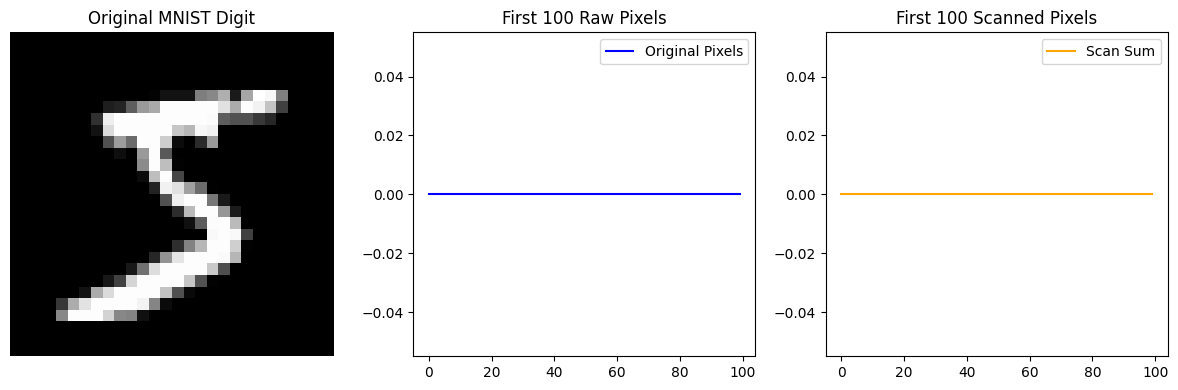

In [1]:
# task2_mnist_scan.py
import cupy as cp
import tensorflow as tf
import matplotlib.pyplot as plt

def run_task2():
    print("--- Task 2: DS4 Parallel Prefix Scan ---")

    # 1. Fetch MNIST Dataset
    print("Fetching MNIST Dataset...")
    (x_train, _), _ = tf.keras.datasets.mnist.load_data()
    mnist_image = x_train[0].astype(cp.float32)

    # 2. Move to GPU and Flatten
    d_image = cp.array(mnist_image)
    d_flattened = d_image.flatten()

    # 3. Execute Parallel Prefix Scan via CUDA Primitives
    d_scan_result = cp.cumsum(d_flattened)

    # 4. Bring back to CPU for evaluation
    h_scan_result = cp.asnumpy(d_scan_result)
    h_flattened = cp.asnumpy(d_flattened)

    print(f"Flattened Array Size: {d_flattened.size} pixels.")
    print(f"Final Scanned Cumulative Sum Value: {h_scan_result[-1]}")

    # 5. Plot Results
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(x_train[0], cmap='gray')
    axes[0].set_title("Original MNIST Digit")
    axes[0].axis('off')

    axes[1].plot(h_flattened[:100], label="Original Pixels", color='blue')
    axes[1].set_title("First 100 Raw Pixels")
    axes[1].legend()

    axes[2].plot(h_scan_result[:100], label="Scan Sum", color='orange')
    axes[2].set_title("First 100 Scanned Pixels")
    axes[2].legend()

    plt.tight_layout()
    print("Displaying visualization plots...")
    plt.show()

if __name__ == "__main__":
    run_task2()